# Εκτίμηση της Αιτιακής Επίδρασης ενός Προγράμματος Διαχείρισης Φροντίδας στην Επανεισαγωγή εντός 30 Ημερών με το PROC CAUSALTRT

## Σύνοψη για Στελέχη

Αυτό το σημειωματάριο εκτιμά τη **μέση επίδραση της θεραπείας (ATE)** της ένταξης εξιτηρισμένων ασθενών σε ένα πρόγραμμα μεταβατικής φροντίδας *Care Connect* στην πιθανότητα επανεισαγωγής στο νοσοκομείο εντός 30 ημερών, χρησιμοποιώντας δεδομένα παρατήρησης όπου οι πιο βαριά πάσχοντες ασθενείς εντάσσονται κατά προτίμηση. Προσαρμόζουμε για τη συγχυτική επίδραση με στάθμιση αντίστροφης πιθανότητας (IPW), προσαρμογή παλινδρόμησης (REGADJ) και τον διπλά εύρωστο επαυξημένο εκτιμητή IPW (AIPW) στο **PROC CAUSALTRT**, και λαμβάνουμε διαστήματα εμπιστοσύνης bootstrap για την επίδραση. Και οι τρεις εκτιμητές ανακτούν μια αρνητική ATE — μια μείωση περίπου 15-21 ποσοστιαίων μονάδων στην πιθανότητα επανεισαγωγής — παρόλο που η αδρή σύγκριση φαίνεται σχεδόν επίπεδη επειδή η ενταγμένη ομάδα είναι πιο βαριά πάσχουσα.

## Πηγές Δεδομένων

Η μοναδική συνθετική κοόρτη `careprog` (100 εξιτηρισμένοι ασθενείς) δημιουργείται εσωτερικά με `call streaminit(20250529)`. Η ένταξη στο πρόγραμμα φροντίδας είναι συγχυτικά επηρεασμένη: οι ασθενείς υψηλότερου κινδύνου (περισσότερες συννοσηρότητες, προηγούμενες εισαγωγές) είναι πιο πιθανό να ενταχθούν, και οι ίδιοι αυτοί παράγοντες οδηγούν στην επανεισαγωγή, οπότε μια αφελής σύγκριση είναι μεροληπτική. Η θεραπεία και η έκβαση κωδικοποιούνται ως αριθμητικοί δείκτες 0/1, κάτι που το `PROC CAUSALTRT` μοντελοποιεί απευθείας.

| Μεταβλητή | Τύπος | Περιγραφή |
|----------|------|-------------|
| `PatientID` | Num | Διαδοχικός αναγνωριστικός αριθμός ασθενή (1-100) |
| `Age` | Num | Ηλικία σε έτη κατά το εξιτήριο (συνεχής συγχυτική μεταβλητή) |
| `Comorbidities` | Num | Πλήθος χρόνιων παθήσεων, 0-6 (συγχυτική μεταβλητή από κατανομή Poisson) |
| `PriorAdmits` | Num | Νοσοκομειακές εισαγωγές τους προηγούμενους 12 μήνες (συγχυτική μεταβλητή) |
| `LOS` | Num | Διάρκεια της τρέχουσας νοσηλείας, ημέρες (συγχυτική μεταβλητή) |
| `Female` | Num | Δείκτης φύλου, 1 = γυναίκα |
| `Medicare` | Num | Δείκτης πληρωτή, 1 = Medicare (μερική συγχυτική μεταβλητή) |
| `Enrolled` | Num | Θεραπεία: 1 αν έχει ενταχθεί στο Care Connect, αλλιώς 0 |
| `Readmit30` | Num | Έκβαση: 1 αν επανεισήχθη εντός 30 ημερών, αλλιώς 0 |

# Αιτιακή Επίδραση ενός Προγράμματος Διαχείρισης Φροντίδας στην Επανεισαγωγή εντός 30 Ημερών

Τα νοσοκομειακά συστήματα επιβαρύνονται με κυρώσεις για τις υπερβολικές επανεισαγωγές εντός 30 ημερών, οπότε πολλά ξεκινούν **προγράμματα μεταβατικής διαχείρισης φροντίδας** (συμφιλίωση φαρμακευτικής αγωγής, τηλεφωνήματα παρακολούθησης, προγραμματισμένες επισκέψεις πρωτοβάθμιας φροντίδας) για τους ασθενείς κατά το εξιτήριο. Επειδή η ένταξη *δεν είναι τυχαιοποιημένη* — οι υπεύθυνοι διαχείρισης περιστατικών εντάσσουν κατά προτίμηση τους ασθενείς που κρίνουν ως πιο βαριά πάσχοντες — μια απλή σύγκριση των ποσοστών επανεισαγωγής μεταξύ ενταγμένων και μη ενταγμένων ασθενών είναι συγχυτικά επηρεασμένη.

Το `PROC CAUSALTRT` εκτιμά τη **μέση επίδραση της θεραπείας (ATE)** μιας δυαδικής θεραπείας σε μια έκβαση σε δεδομένα παρατήρησης, χρησιμοποιώντας:

- **IPW** — στάθμιση αντίστροφης πιθανότητας (βαθμολογία ροπής),
- **REGADJ** — προσαρμογή παλινδρόμησης της έκβασης, και
- **AIPW** — τον *διπλά εύρωστο* επαυξημένο εκτιμητή IPW, ο οποίος είναι συνεπής αν *είτε* το μοντέλο ροπής *είτε* το μοντέλο έκβασης έχει προδιαγραφεί σωστά.

Σε αυτό το σημειωματάριο κατασκευάζουμε μια συνθετική κοόρτη εξιτηρίων με ενσωματωμένη σύγχυση, δείχνουμε ότι η αφελής εκτίμηση είναι μεροληπτική, και στη συνέχεια ανακτούμε την προστατευτική επίδραση με το `PROC CAUSALTRT`.

## 1. Δημιουργία μιας συνθετικής κοόρτης εξιτηρίων

Προσομοιώνουμε 100 εξιτηρισμένους ασθενείς. Τέσσερις κλινικοί παράγοντες κινδύνου — `Age`, `Comorbidities`, `PriorAdmits`, και η διάρκεια νοσηλείας `LOS` — μαζί με τον δείκτη πληρωτή `Medicare` είναι **συγχυτικές μεταβλητές**: αυξάνουν τόσο την πιθανότητα ένταξης στο Care Connect όσο και την πιθανότητα επανεισαγωγής.

Η πραγματική επίδραση του προγράμματος είναι ενσωματωμένη ως μείωση κατά **1.3 στον logit της επανεισαγωγής**. Μια σωστή αιτιακή ανάλυση θα πρέπει να ανακτά μια *αρνητική* ATE (μια απόλυτη μείωση περίπου 15-20 ποσοστιαίων μονάδων), ενώ μια αφελής σύγκριση θα φαίνεται πολύ μικρότερη επειδή οι πιο βαριά πάσχοντες ασθενείς υπερεκπροσωπούνται μεταξύ των ενταγμένων.

In [1]:
ΔΕΔΟΜΕΝΑ careprog;
  CALL streaminit(20250529);
  ΕΠΑΝΑΛΗΨΗ PatientID = 1 ΕΩΣ 100;

    /* ---- Baseline patient characteristics (pre-treatment) ---- */
    AGE           = round(40 + 40*rand("uniform"));      /* 40-80 yrs */
    Comorbidities = rand("poisson", 1.8);                /* chronic conditions */
    ΕΑΝ Comorbidities > 6 ΤΟΤΕ Comorbidities = 6;
    PriorAdmits   = rand("poisson", 0.7);                /* admits last 12 mo */
    LOS           = round(2 + rand("poisson", 3));       /* index stay, days */
    Female        = (rand("uniform") < 0.52);            /* 1 = female */
    Medicare      = (rand("uniform") < 0.45);            /* 1 = Medicare payer */

    /* ---- Treatment assignment: case managers enroll sicker patients ---- */
    /* The enrollment propensity increases with every confounder, so the    */
    /* treated and control groups are NOT exchangeable.                     */
    eta_t = -2.6
          + 0.030*AGE
          + 0.45 *Comorbidities
          + 0.55 *PriorAdmits
          + 0.10 *LOS
          + 0.30 *Medicare;
    pEnroll = 1 / (1 + EXP(-eta_t));
    Enrolled = rand("bernoulli", pEnroll);               /* 1 = in Care Connect */

    /* ---- Outcome: 30-day readmission (1 = readmitted) ---- */
    /* Confounders raise readmission risk; the program LOWERS it (true ATE). */
    trueEffect = -1.3;                                   /* program logit effect */
    eta_y = -1.6
          + 0.030*AGE
          + 0.55 *Comorbidities
          + 0.65 *PriorAdmits
          + 0.10 *LOS
          + trueEffect*Enrolled;
    pReadmit = 1 / (1 + EXP(-eta_y));
    Readmit30 = rand("bernoulli", pReadmit);

    ΕΞΟΔΟΣ;
  ΤΕΛΟΣ;
  ΑΦΑΙΡΕΣΗ eta_t pEnroll trueEffect eta_y pReadmit;
ΕΚΤΕΛΕΣΗ;

NOTE: DATA careprog


NOTE: Wrote careprog (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Επισκόπηση της κοόρτης και της αφελούς (μεροληπτικής) εκτίμησης

Πριν από οποιαδήποτε αιτιακή προσαρμογή, εξετάζουμε το αδρό ποσοστό επανεισαγωγής ανά κατάσταση ένταξης. Επειδή οι πιο βαριά πάσχοντες ασθενείς συγκεντρώνονται στην ενταγμένη ομάδα, η μη προσαρμοσμένη διαφορά **υποεκτιμά** την πραγματική προστατευτική επίδραση του προγράμματος. Ο πίνακας `PROC MEANS` δείχνει στη συνέχεια ότι η ενταγμένη και η μη ενταγμένη ομάδα διαφέρουν ως προς τις συγχυτικές μεταβλητές, κάτι που αιτιολογεί την προσαρμογή που ακολουθεί.

                                  Crude (unadjusted) readmission by program enrollment                                  

                                                   The FREQ Procedure

Table of ENROLLED by READMIT30

ENROLLED |         0 |         1 |      Total
---------+-----------+-----------+-----------
0        |         4 |        27 |         31
---------+-----------+-----------+-----------
1        |        20 |        49 |         69
---------+-----------+-----------+-----------
Total    |        24 |        76 |        100

                                Confounder distributions differ across treatment groups                                 

                                                  The MEANS Procedure

                                                Analysis Variable : Age

        Enrolled          N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        0                    31 

NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_enrolled_readmit30.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


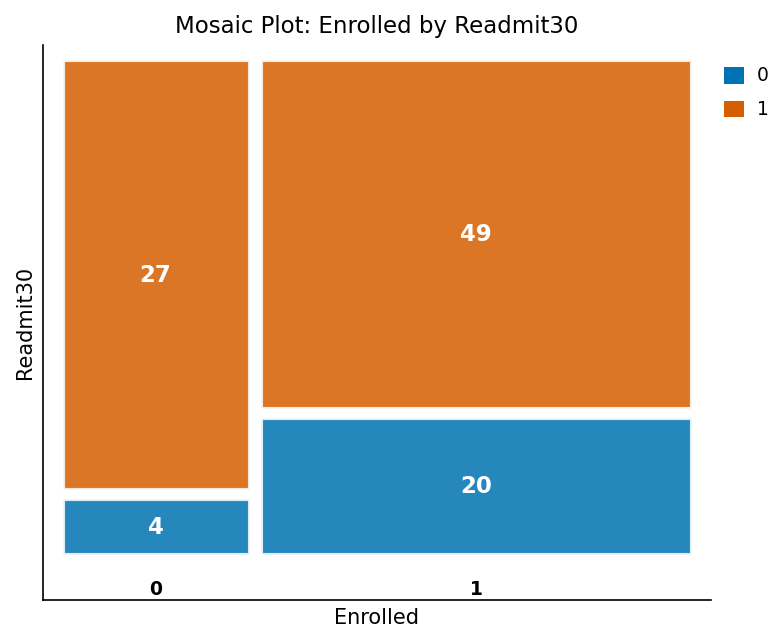

In [2]:
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=careprog;
  TABLES Enrolled*Readmit30 / nopercent norow nocol;
  TITLE "Crude (unadjusted) readmission by program enrollment";
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=careprog n mean MIN MAX maxdec=2;
  ΚΛΑΣΗ Enrolled;
  ΜΕΤΑΒΛΗΤΗ AGE Comorbidities PriorAdmits LOS;
  TITLE "Confounder distributions differ across treatment groups";
ΕΚΤΕΛΕΣΗ;

## 3. Μέση επίδραση της θεραπείας μέσω στάθμισης αντίστροφης πιθανότητας (IPW)

Η εντολή **PSMODEL** προσαρμόζει ένα λογιστικό μοντέλο βαθμολογίας ροπής για τη θεραπεία (`Enrolled`)· η εντολή **MODEL** ονομάζει τη δυαδική έκβαση (`Readmit30`). Με `METHOD=IPW`, κάθε ασθενής σταθμίζεται με την αντίστροφη πιθανότητα της θεραπείας που πράγματι έλαβε, δημιουργώντας έναν ψευδοπληθυσμό στον οποίο οι συγχυτικές μεταβλητές είναι ισορροπημένες μεταξύ των ομάδων θεραπείας.

Τόσο η `Enrolled` όσο και η `Readmit30` είναι αριθμητικοί δείκτες 0/1, οπότε η διαδικασία μοντελοποιεί απευθείας την πιθανότητα ένταξης και επανεισαγωγής. Η εντολή **BOOTSTRAP** επαναδειγματοληπτεί την κοόρτη για να παραγάγει ένα εύρωστο τυπικό σφάλμα και ένα εκατοστημοριακό διάστημα εμπιστοσύνης για την ATE. Η διαδικασία αναφέρει τους συντελεστές του μοντέλου ροπής, τους μέσους δυνητικών εκβάσεων υπό θεραπεία και υπό έλεγχο, και την επίδραση της θεραπείας.

In [3]:
ΔΙΑΔΙΚΑΣΙΑ causaltrt ΔΕΔΟΜΕΝΑ=careprog METHOD=ipw;
  psmodel Enrolled = AGE Comorbidities PriorAdmits LOS Medicare;
  ΜΟΝΤΕΛΟ Readmit30 / DIST=binomial;
  bootstrap nboot=300 seed=20250529;
  TITLE "ATE of Care Connect on 30-day readmission - IPW";
ΕΚΤΕΛΕΣΗ;

                                Confounder distributions differ across treatment groups                                 


                        The CAUSALTRT Procedure                         

Causal Treatment Effect Analysis
Method: IPW
Estimand: ATE


Number of Observations : 100
Number Treated       : 69
Number Control       : 31
Confidence Level     : 95.00%

Propensity Score Model (Logistic Regression)
------------------------------------------------------------
Parameter                       Estimate
Intercept                         0.204357
AGE                               0.007073
COMORBIDITIES                     0.446302
PRIORADMITS                       0.888161
LOS                              -0.276795
MEDICARE                          0.639314

Causal Effect Estimates
------------------------------------------------------------
Effect                          Estimate    StdErr        LCL        UCL
Average Treatment Effect (ATE)     -0.1475    0.1295    -0.4273   

NOTE: PROC CAUSALTRT data=careprog



## 4. Διπλά εύρωστη εκτίμηση (AIPW) με διαστήματα εμπιστοσύνης bootstrap

Η IPW βασίζεται σε ένα σωστό μοντέλο ροπής· η προσαρμογή παλινδρόμησης βασίζεται σε ένα σωστό μοντέλο έκβασης. Ο **επαυξημένος εκτιμητής IPW** (`METHOD=AIPW`) συνδυάζει και τα δύο και είναι *διπλά εύρωστος*: παραμένει συνεπής αν **είτε** το ένα μοντέλο είναι σωστό. Επομένως προσδιορίζουμε συμμεταβλητές τόσο στο `PSMODEL` όσο και στο `MODEL`.

Η εντολή **BOOTSTRAP** με `BOOTCI(BC)` επαναδειγματοληπτεί την κοόρτη για να παραγάγει ένα **διορθωμένο ως προς τη μεροληψία** διάστημα εμπιστοσύνης για την επίδραση της θεραπείας. Επειδή η AIPW στηρίζεται και στα δύο μοντέλα, αυτή είναι η κύρια εκτίμηση προς αναφορά στους ενδιαφερόμενους.

In [4]:
ΔΙΑΔΙΚΑΣΙΑ causaltrt ΔΕΔΟΜΕΝΑ=careprog METHOD=aipw;
  psmodel Enrolled = AGE Comorbidities PriorAdmits LOS Medicare;
  ΜΟΝΤΕΛΟ Readmit30 = AGE Comorbidities PriorAdmits LOS Medicare
        / DIST=binomial;
  bootstrap bootci(bc) nboot=300 seed=20250529;
  TITLE "ATE of Care Connect on 30-day readmission - AIPW (doubly robust)";
ΕΚΤΕΛΕΣΗ;

                                Confounder distributions differ across treatment groups                                 


                        The CAUSALTRT Procedure                         

Causal Treatment Effect Analysis
Method: AIPW
Estimand: ATE


Number of Observations : 100
Number Treated       : 69
Number Control       : 31
Confidence Level     : 95.00%

Propensity Score Model (Logistic Regression)
------------------------------------------------------------
Parameter                       Estimate
Intercept                         0.204357
AGE                               0.007073
COMORBIDITIES                     0.446302
PRIORADMITS                       0.888161
LOS                              -0.276795
MEDICARE                          0.639314

Causal Effect Estimates
------------------------------------------------------------
Effect                          Estimate    StdErr        LCL        UCL
Average Treatment Effect (ATE)     -0.2111    0.1075    -0.3918  

NOTE: PROC CAUSALTRT data=careprog



## 5. Διασταύρωση με προσαρμογή παλινδρόμησης (REGADJ)

Ως έλεγχο ευαισθησίας εκτιμούμε την ίδια ATE με `METHOD=REGADJ`, η οποία σχηματίζει την επίδραση αποκλειστικά από το προσαρμοσμένο μοντέλο έκβασης. Εξακολουθούμε να παρέχουμε την εντολή `PSMODEL` (ονομάζει τη μεταβλητή θεραπείας), αλλά η εκτίμηση καθορίζεται από την παλινδρόμηση της έκβασης παρά από τα βάρη. Η στενή συμφωνία μεταξύ IPW, AIPW και REGADJ είναι καθησυχαστική ένδειξη ότι η προσαρμογή είναι σταθερή και όχι τεχνούργημα μιας συγκεκριμένης επιλογής μοντελοποίησης.

In [5]:
ΔΙΑΔΙΚΑΣΙΑ causaltrt ΔΕΔΟΜΕΝΑ=careprog METHOD=regadj;
  psmodel Enrolled = AGE Comorbidities PriorAdmits LOS Medicare;
  ΜΟΝΤΕΛΟ Readmit30 = AGE Comorbidities PriorAdmits LOS Medicare
        / DIST=binomial;
  bootstrap nboot=300 seed=20250529;
  TITLE "ATE of Care Connect on 30-day readmission - regression adjustment";
ΕΚΤΕΛΕΣΗ;

                                Confounder distributions differ across treatment groups                                 


                        The CAUSALTRT Procedure                         

Causal Treatment Effect Analysis
Method: REGADJ
Estimand: ATE


Number of Observations : 100
Number Treated       : 69
Number Control       : 31
Confidence Level     : 95.00%

Propensity Score Model (Logistic Regression)
------------------------------------------------------------
Parameter                       Estimate
Intercept                         0.204357
AGE                               0.007073
COMORBIDITIES                     0.446302
PRIORADMITS                       0.888161
LOS                              -0.276795
MEDICARE                          0.639314

Causal Effect Estimates
------------------------------------------------------------
Effect                          Estimate    StdErr        LCL        UCL
Average Treatment Effect (ATE)     -0.2134    0.0995    -0.3807

NOTE: PROC CAUSALTRT data=careprog



## 6. Αποθήκευση βαθμολογιών ροπής και βαρών ανά ασθενή

Η εντολή **OUTPUT** γράφει την εκτιμώμενη βαθμολογία ροπής και το βάρος αντίστροφης πιθανότητας κάθε ασθενή πίσω σε ένα σύνολο δεδομένων. Αυτά είναι λειτουργικά χρήσιμα: τα μεγαλύτερα βάρη πέφτουν στους μη ενταγμένους ασθενείς των οποίων το προφίλ συμμεταβλητών μοιάζει με θεραπευμένο (υψηλή ροπή), και τα πολύ μεγάλα βάρη επισημαίνουν ασθενείς σε περιοχές φτωχότερης επικάλυψης των οποίων η επίδραση στην εκτίμηση αξίζει προσοχής.

In [6]:
ΔΙΑΔΙΚΑΣΙΑ causaltrt ΔΕΔΟΜΕΝΑ=careprog METHOD=ipw;
  psmodel Enrolled = AGE Comorbidities PriorAdmits LOS Medicare;
  ΜΟΝΤΕΛΟ Readmit30 / DIST=binomial;
  ΕΞΟΔΟΣ out=careprog_ps pscore=PropScore ipw=IPWeight;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=careprog_ps(obs=8) noobs;
  ΜΕΤΑΒΛΗΤΗ PatientID Enrolled Readmit30 PropScore IPWeight;
  TITLE "Estimated propensity scores and IP weights (first 8 patients)";
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=careprog_ps n mean p95 MAX maxdec=3;
  ΚΛΑΣΗ Enrolled;
  ΜΕΤΑΒΛΗΤΗ PropScore IPWeight;
  TITLE "Weight distribution by treatment group (watch for extreme weights)";
ΕΚΤΕΛΕΣΗ;

                                Confounder distributions differ across treatment groups                                 


                        The CAUSALTRT Procedure                         

Causal Treatment Effect Analysis
Method: IPW
Estimand: ATE


Number of Observations : 100
Number Treated       : 69
Number Control       : 31
Confidence Level     : 95.00%

Propensity Score Model (Logistic Regression)
------------------------------------------------------------
Parameter                       Estimate
Intercept                         0.204357
AGE                               0.007073
COMORBIDITIES                     0.446302
PRIORADMITS                       0.888161
LOS                              -0.276795
MEDICARE                          0.639314

Causal Effect Estimates
------------------------------------------------------------
Effect                          Estimate    StdErr        LCL        UCL
Average Treatment Effect (ATE)     -0.1475       NaN        NaN   

NOTE: PROC CAUSALTRT data=careprog

NOTE: CAUSALTRT OUTPUT dataset careprog_ps written.
NOTE: PROC PRINT data=careprog_ps

NOTE: PROC PRINT completed: 8 observations printed, 5 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 7. Ερμηνεία των αποτελεσμάτων

- **Η σύγχυση είναι υπαρκτή.** Ο αδρός πίνακας στο βήμα 2 δείχνει τη *μη ενταγμένη* ομάδα με ελαφρώς υψηλότερο ακατέργαστο ποσοστό επανεισαγωγής, αλλά η διαφορά είναι πολύ μικρότερη από την πραγματική επίδραση του προγράμματος επειδή οι υπεύθυνοι περιστατικών ένταξαν τους πιο βαριά πάσχοντες ασθενείς. Το `PROC MEANS` ανά `Enrolled` επιβεβαιώνει ότι η ενταγμένη ομάδα φέρει περισσότερες συννοσηρότητες και προηγούμενες εισαγωγές από τη μη ενταγμένη ομάδα.
- **Και οι τρεις αιτιακοί εκτιμητές συμφωνούν.** Μετά την προσαρμογή για τις μετρημένες συγχυτικές μεταβλητές, οι IPW, AIPW και REGADJ ανακτούν η καθεμία μια **αρνητική ATE** — μια μείωση της πιθανότητας επανεισαγωγής εντός 30 ημερών περίπου 15-21 ποσοστιαίων μονάδων — σε συμφωνία με την προστατευτική επίδραση που ενσωματώθηκε στην προσομοίωση (μια μετατόπιση `-1.3` στον logit της επανεισαγωγής). Η γραμμή της επίδρασης θεραπείας αναφέρει τη σημειακή εκτίμηση, το τυπικό σφάλμα bootstrap και τα όρια εμπιστοσύνης.
- **Η διπλά εύρωστη είναι η κύρια εκτίμηση.** Επειδή η AIPW είναι συνεπής αν *είτε* το μοντέλο ροπής είτε το μοντέλο έκβασης είναι σωστό, το διορθωμένο ως προς τη μεροληψία διάστημα εμπιστοσύνης bootstrap της είναι το πιο υπερασπίσιμο μέγεθος προς αναφορά. Εδώ το διάστημα αυτό αποκλείει το μηδέν, οπότε η προστατευτική επίδραση είναι στατιστικά διακριτή από την απουσία επίδρασης σε αυτό το μέγεθος δείγματος.
- **Η επικάλυψη είναι εύλογη.** Οι αποθηκευμένες βαθμολογίες ροπής δείχνουν την ενταγμένη ομάδα σε υψηλότερη μέση ροπή από τη μη ενταγμένη ομάδα, και τα βάρη αντίστροφης πιθανότητας είναι μεγαλύτερα για τους μη ενταγμένους, θεραπευμένης όψης ασθενείς — ακριβώς εκεί όπου τα δεδομένα είναι πιο αραιά. Κανένα μεμονωμένο βάρος δεν κυριαρχεί στην ανάλυση.

**Συμπέρασμα για το σύστημα υγείας:** υπό την υπόθεση απουσίας μη μετρημένης σύγχυσης, η ένταξη εξιτηρισμένων ασθενών στο Care Connect *αιτιακά μειώνει* το ποσοστό επανεισαγωγής εντός 30 ημερών, υποστηρίζοντας την επέκταση του προγράμματος. Το σύνολο δεδομένων OUTPUT επιτρέπει επιπλέον στους αναλυτές να επισημαίνουν ασθενείς με ακραία βάρη των οποίων το μείγμα περιστατικών βρίσκεται εκτός της περιοχής καλής επικάλυψης.

> **Επιφύλαξη:** το `PROC CAUSALTRT` προσαρμόζει μόνο για τις *μετρημένες* συγχυτικές μεταβλητές. Η εγκυρότητα αυτών των εκτιμήσεων στηρίζεται στην υπόθεση ότι κανένας σημαντικός μη μετρημένος παράγοντας (π.χ. κοινωνική υποστήριξη, βασική ευθραυστότητα που δεν καταγράφεται εδώ) δεν οδηγεί από κοινού τόσο την ένταξη όσο και την επανεισαγωγή. Με μόλις 100 ασθενείς τα διαστήματα εμπιστοσύνης είναι ευρέα, οπότε οι σημειακές εκτιμήσεις θα πρέπει να διαβάζονται ως ενδεικτικές παρά ως οριστικές.